In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Switch from CPU to GPU in PyTorch
Handle two separate things: the hardware setting in Google Colab and the code implementation to move your data and model onto that hardware.

## 1. Enable GPU in Colab Settings

Before the code can detect a GPU, you must attach one to your virtual machine:

- Look at the top right of your Colab screen and click the down arrow next to the RAM/Disk meter (or go to the Runtime menu).
- Select Change runtime type.
- Under Hardware accelerator, select T4 GPU (or any available GPU).
- Click Save.

Note: This will restart your session, so you'll need to re-run your import cells.

In [19]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Augmentation for better generalization
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Download EuroSAT Dataset (Built-in to Torchvision)
full_dataset = datasets.EuroSAT(root='./data', download=True, transform=transform)

# Split into Train (80%) and Validation (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

class_names = full_dataset.classes
print(f"Classes: {class_names}")

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Build the Model (Transfer Learning)

Instead of training from scratch, we use a pre-trained ResNet18. We "freeze" the early layers (which detect basic shapes) and replace the final "head" to match our 10 satellite classes.

## 2. Move model to GPU (line 9)

In [20]:
# Load pre-trained ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')

# Replace the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

# Move model to GPU (******)
model = model.to(device)

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
# Train model
def train_model(model, criterion, optimizer, epochs=5):
    epoch_losses = [] # Initialize list to store losses
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_losses.append(epoch_loss) # Store the loss
        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")
    return epoch_losses # Return the list of losses

model_train_losses = train_model(model, criterion, optimizer, epochs=3)

Epoch 1/3 - Loss: 0.4358
Epoch 2/3 - Loss: 0.2389
Epoch 3/3 - Loss: 0.1932


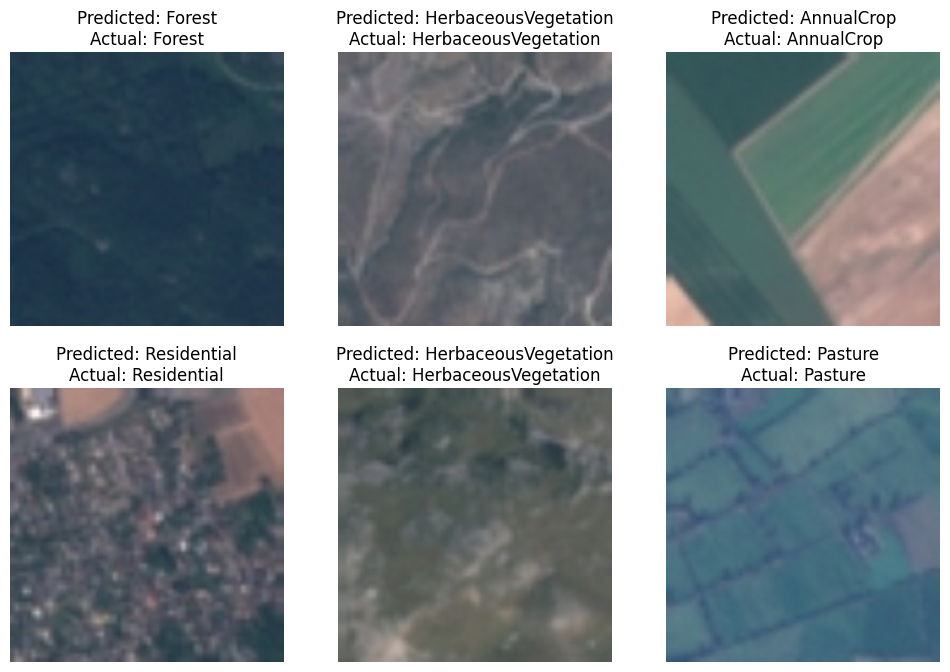

In [22]:
# Visualize predictions
def visualize_results(model, num_images=6):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(12, 8))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(val_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 3, 3, images_so_far)
                ax.axis('off')
                ax.set_title(f'Predicted: {class_names[preds[j]]}\nActual: {class_names[labels[j]]}')

                # Un-normalize for display
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                img = np.clip(np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406]), 0, 1)
                plt.imshow(img)

                if images_so_far == num_images:
                    return

visualize_results(model)

In [23]:
misclassifications = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j: # Only consider off-diagonal elements
            count = cm[i, j]
            if count > 0:
                misclassifications.append({
                    'actual': class_names[i],
                    'predicted': class_names[j],
                    'count': count
                })

# Sort misclassifications by count in descending order
misclassifications.sort(key=lambda x: x['count'], reverse=True)

print("Top 10 Misclassifications:")
for mc in misclassifications[:10]:
    print(f"  Actual: {mc['actual']} was predicted as {mc['predicted']}, {mc['count']} times")

Top 10 Misclassifications:
  Actual: HerbaceousVegetation was predicted as PermanentCrop, 59 times
  Actual: River was predicted as AnnualCrop, 30 times
  Actual: Forest was predicted as HerbaceousVegetation, 18 times
  Actual: Pasture was predicted as AnnualCrop, 18 times
  Actual: River was predicted as Highway, 18 times
  Actual: River was predicted as Pasture, 18 times
  Actual: Forest was predicted as SeaLake, 14 times
  Actual: PermanentCrop was predicted as AnnualCrop, 14 times
  Actual: PermanentCrop was predicted as HerbaceousVegetation, 11 times
  Actual: AnnualCrop was predicted as PermanentCrop, 9 times


F1-Score (weighted): 0.9498
Accuracy: 0.9498


<Figure size 1000x800 with 0 Axes>

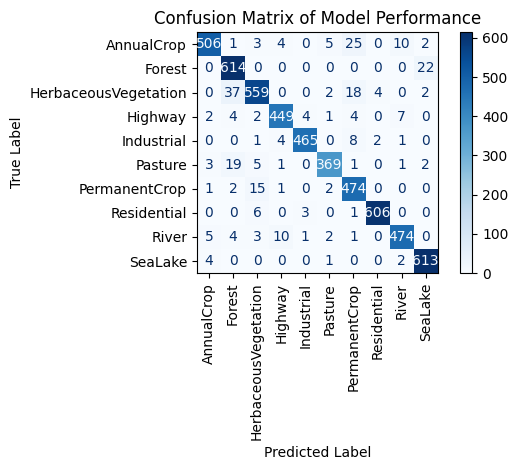

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, accuracy_score

def evaluate_model(model, data_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

actual_labels, predicted_labels = evaluate_model(model, val_loader, class_names)
cm = confusion_matrix(actual_labels, predicted_labels)

f1 = f1_score(actual_labels, predicted_labels, average='weighted')
accuracy = accuracy_score(actual_labels, predicted_labels)

print(f"F1-Score (weighted): {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix of Model Performance')
plt.xticks(rotation=90)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


## Fine-tuning the Model by Unfreezing Earlier Layers

To fine-tune, we'll load another instance of the ResNet18 model, unfreeze all its layers, and then train it for a few more epochs with a lower learning rate. This allows the pre-trained layers to adapt more specifically to our EuroSAT dataset.

In [25]:
# Load a new pre-trained ResNet18 instance for fine-tuning
fine_tuned_model = models.resnet18(weights='IMAGENET1K_V1')

# Replace the final fully connected layer
num_ftrs_ft = fine_tuned_model.fc.in_features
fine_tuned_model.fc = nn.Linear(num_ftrs_ft, len(class_names))

# Unfreeze all model parameters for fine-tuning
for param in fine_tuned_model.parameters():
    param.requires_grad = True

# Move the fine-tuned model to GPU
fine_tuned_model = fine_tuned_model.to(device)

# Define a new optimizer with a lower learning rate for fine-tuning
# It's common to use a much smaller learning rate when fine-tuning to avoid overfitting
fine_tune_optimizer = optim.Adam(fine_tuned_model.parameters(), lr=0.0001)

print("Fine-tuning model prepared: all layers unfrozen with a new optimizer.")

Fine-tuning model prepared: all layers unfrozen with a new optimizer.


In [26]:
# Train this unfrozen model
print("Starting fine-tuning...")
fine_tuned_model_train_losses = train_model(fine_tuned_model, criterion, fine_tune_optimizer, epochs=3)
print("Fine-tuning complete.")

Starting fine-tuning...
Epoch 1/3 - Loss: 0.2082
Epoch 2/3 - Loss: 0.0926
Epoch 3/3 - Loss: 0.0647
Fine-tuning complete.


## Evaluate the performance between fine-tuning model and initial model

<Figure size 1000x800 with 0 Axes>

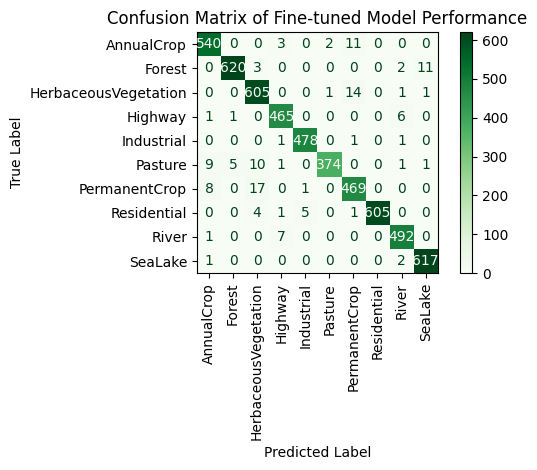


--- Performance Comparison ---
Initial Model (Frozen Layers):
  Accuracy: 0.9498
  F1-Score: 0.9498

Fine-tuned Model (Unfrozen Layers):
  Accuracy: 0.9750
  F1-Score: 0.9750


In [27]:
# Evaluate the fine-tuned model
actual_labels_ft, predicted_labels_ft = evaluate_model(fine_tuned_model, val_loader, class_names)
f1_ft = f1_score(actual_labels_ft, predicted_labels_ft, average='weighted')
accuracy_ft = accuracy_score(actual_labels_ft, predicted_labels_ft)

# Plot Confusion Matrix for Fine-tuned Model
cm_ft = confusion_matrix(actual_labels_ft, predicted_labels_ft)
plt.figure(figsize=(10, 8))
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names)
disp_ft.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix of Fine-tuned Model Performance')
plt.xticks(rotation=90)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


print(f"\n--- Performance Comparison ---")
print(f"Initial Model (Frozen Layers):\n  Accuracy: {accuracy:.4f}\n  F1-Score: {f1:.4f}")
print(f"\nFine-tuned Model (Unfrozen Layers):\n  Accuracy: {accuracy_ft:.4f}\n  F1-Score: {f1_ft:.4f}")


## Plotting Training Loss Over Epochs

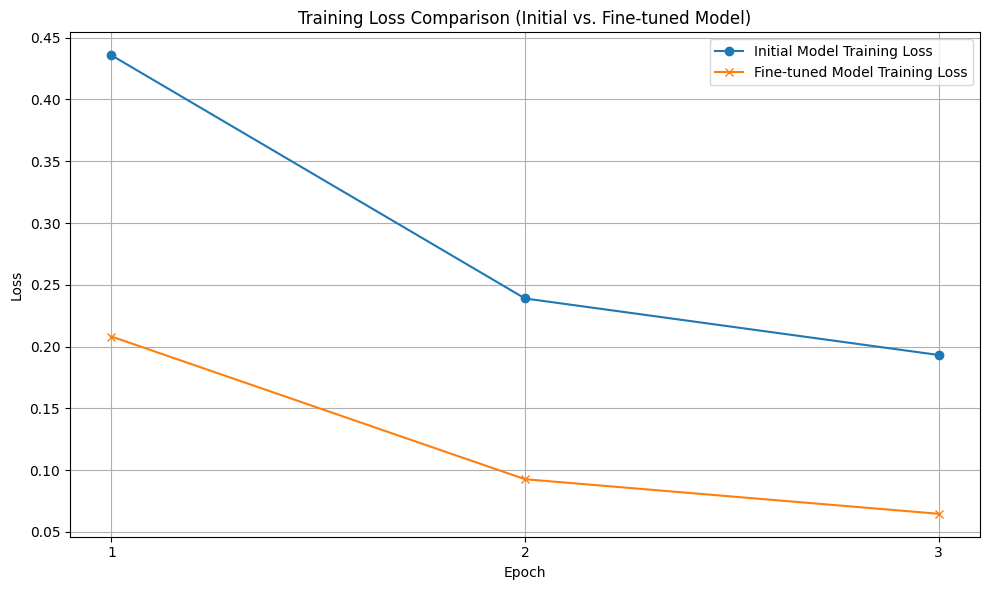

In [28]:
import matplotlib.pyplot as plt

# The loss lists are now directly available from the training functions
initial_losses = model_train_losses
fine_tuned_losses = fine_tuned_model_train_losses

epochs = range(1, len(initial_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, initial_losses, label='Initial Model Training Loss', marker='o')
plt.plot(epochs, fine_tuned_losses, label='Fine-tuned Model Training Loss', marker='x')
plt.title('Training Loss Comparison (Initial vs. Fine-tuned Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()